**HW13: Токенизация текста, инференс готовой BERT-подобной модели и базовый fine-tuning для классификации текста.**

# 1. Импорты

In [1]:
# Импорты, seed, устройство
import random
import numpy as np
import os
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

print(f"PyTorch: {torch.__version__}")

# Монтирование Google Drive
from google.colab import drive
drive.mount('/content/drive')

Device: cuda
PyTorch: 2.10.0+cu128
Mounted at /content/drive


# 2.Загрузка датасета и первичный анализ

In [2]:
# Данные и первичный анализ
dataset = load_dataset("emotion")
print(f"Train: {len(dataset['train'])}")
print(f"Validation: {len(dataset['validation'])}")
print(f"Test: {len(dataset['test'])}")

label_names = dataset['train'].features['label'].names
print(f"Classes ({len(label_names)}): {label_names}")

# Примеры
for i in range(5):
    print(f"\nText: {dataset['train'][i]['text']}")
    print(f"Label: {label_names[dataset['train'][i]['label']]}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Train: 16000
Validation: 2000
Test: 2000
Classes (6): ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

Text: i didnt feel humiliated
Label: sadness

Text: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Label: sadness

Text: im grabbing a minute to post i feel greedy wrong
Label: anger

Text: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Label: love

Text: i am feeling grouchy
Label: anger


# 3. Токенизация на примерах

In [3]:
#Токенизация
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

samples = [dataset['train'][i]['text'] for i in range(3)]
for text in samples:
    tokens = tokenizer(text, padding=False, truncation=False)
    print(f"\nText: {text[:50]}...")
    print(f"Tokens: {tokenizer.convert_ids_to_tokens(tokens['input_ids'])}")
    print(f"Input IDs: {tokens['input_ids']}")
    print(f"Attention mask: {tokens['attention_mask']}")

# Пример padding/truncation
padded = tokenizer(samples[0], padding='max_length', max_length=20, truncation=True)
print(f"\nPadding example - length: {len(padded['input_ids'])}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Text: i didnt feel humiliated...
Tokens: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]']
Input IDs: [101, 1045, 2134, 2102, 2514, 26608, 102]
Attention mask: [1, 1, 1, 1, 1, 1, 1]

Text: i can go from feeling so hopeless to so damned hop...
Tokens: ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake', '[SEP]']
Input IDs: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]
Attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Text: im grabbing a minute to post i feel greedy wrong...
Tokens: ['[CLS]', 'im', 'grabbing', 'a', 'minute', 'to', 'post', 'i', 'feel', 'greedy', 'wrong', '[SEP]']
Input IDs: [101, 10047, 9775, 1037, 3371, 2000, 2695, 1045, 2514, 20505, 3308, 102]
Attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Paddin

# 4.  Инференс готовой модели

In [4]:
# Инференс готовой модели
inference_model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)
inference_model.eval()

test_texts = [dataset['test'][i]['text'] for i in range(5)]
true_labels = [label_names[dataset['test'][i]['label']] for i in range(5)]

for text, true in zip(test_texts, true_labels):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(device)
    with torch.no_grad():
        outputs = inference_model(**inputs)
        pred = torch.argmax(outputs.logits, dim=-1).item()
    print(f"Text: {text[:60]}...")
    print(f"True: {true}, Pred: {label_names[pred]} (raw logits - random, not fine-tuned)\n")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Text: im feeling rather rotten so im not very ambitious right now...
True: sadness, Pred: sadness (raw logits - random, not fine-tuned)

Text: im updating my blog because i feel shitty...
True: sadness, Pred: sadness (raw logits - random, not fine-tuned)

Text: i never make her separate from me because i don t ever want ...
True: sadness, Pred: sadness (raw logits - random, not fine-tuned)

Text: i left with my bouquet of red and yellow tulips under my arm...
True: joy, Pred: sadness (raw logits - random, not fine-tuned)

Text: i was feeling a little vain when i did this one...
True: sadness, Pred: sadness (raw logits - random, not fine-tuned)



# 5. Fine-tuning (подготовка данных)

In [5]:
# Подготовка датасета для fine-tuning
def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

tokenized_dataset = dataset.map(tokenize_function, batched=True)
tokenized_dataset = tokenized_dataset.remove_columns(['text'])
tokenized_dataset = tokenized_dataset.rename_column('label', 'labels')
tokenized_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

print(f"Train shape: {len(tokenized_dataset['train'])}")
print(f"Val shape: {len(tokenized_dataset['validation'])}")
print(f"Test shape: {len(tokenized_dataset['test'])}")

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Train shape: 16000
Val shape: 2000
Test shape: 2000


# 6. Обучение модели

In [6]:
# Fine-tuning (финальная версия)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(label_names)).to(device)

training_args = TrainingArguments(
    seed=SEED,
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds, average='macro')
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['validation'],
    compute_metrics=compute_metrics,
)

trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.227218,0.230490,0.925500,0.901366
2,0.108747,0.147448,0.939000,0.915779
3,0.076446,0.136167,0.943500,0.921940


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=3000, training_loss=0.28078802076975506, metrics={'train_runtime': 572.5866, 'train_samples_per_second': 83.83, 'train_steps_per_second': 5.239, 'total_flos': 1589722177536000.0, 'train_loss': 0.28078802076975506, 'epoch': 3.0})

# 7. Оценка на test и матрица ошибок

Test Accuracy: 0.9305
Test F1 Macro: 0.8798


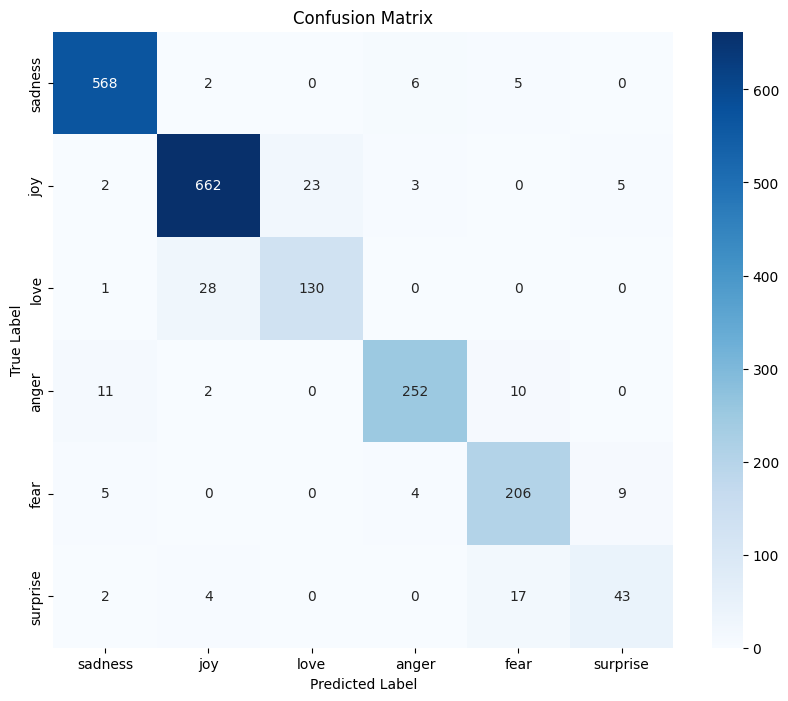

Confusion matrix saved to /content/drive/MyDrive/AIE-SEMINARS/HW13/artifacts/confusion_matrix.png

Всего ошибок в выборке из 50: 2

Примеры ошибок модели:


,text,true_label,pred_label,confidence
10,i don t feel particularly agitated,fear,anger,0.918533
40,i feel if i completely hated things i d exerci...,anger,sadness,0.547569



Saved predictions to /content/drive/MyDrive/AIE-SEMINARS/HW13/artifacts/sample_predictions.csv


,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambiti...,sadness,sadness,0.999582
1,im updating my blog because i feel shitty,sadness,sadness,0.999632
2,i never make her separate from me because i do...,sadness,sadness,0.999620
3,i left with my bouquet of red and yellow tulip...,joy,joy,0.999725
4,i was feeling a little vain when i did this one,sadness,sadness,0.999639
5,i cant walk into a shop anywhere where i do no...,fear,fear,0.999233
6,i felt anger when at the end of a telephone call,anger,anger,0.992490
7,i explain why i clung to a relationship with a...,joy,joy,0.962681
8,i like to have the same breathless feeling as ...,joy,joy,0.999579
9,i jest i feel grumpy tired and pre menstrual w...,anger,anger,0.999493


In [7]:
# Оценка на test и матрица ошибок

drive_path = '/content/drive/MyDrive/AIE-SEMINARS/HW13'
os.makedirs(drive_path, exist_ok=True)
os.makedirs(f'{drive_path}/artifacts', exist_ok=True)

# Предсказания
predictions = trainer.predict(tokenized_dataset['test'])
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

# Метрики
accuracy = accuracy_score(labels, preds)
f1_macro = f1_score(labels, preds, average='macro')

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test F1 Macro: {f1_macro:.4f}")

# Матрица ошибок
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Сохраняем на Google Drive
plt.savefig(f'{drive_path}/artifacts/confusion_matrix.png', bbox_inches='tight')
plt.show()

print(f"Confusion matrix saved to {drive_path}/artifacts/confusion_matrix.png")

# Анализ ошибок (Error Analysis)

# Подготовка данных для predictions.csv (берём первые 50 примеров)
test_texts = dataset['test']['text'][:50]
true_labels_text = [label_names[l] for l in labels[:50]]
pred_labels_text = [label_names[p] for p in preds[:50]]

# Confidence (вероятность предсказанного класса)
probs = torch.nn.functional.softmax(torch.tensor(predictions.predictions), dim=-1)
confidences = [probs[i][preds[i]].item() for i in range(50)]

df_predictions = pd.DataFrame({
    'text': test_texts,
    'true_label': true_labels_text,
    'pred_label': pred_labels_text,
    'confidence': confidences
})

# Фильтруем только ошибки и показываем их
errors_df = df_predictions[df_predictions['true_label'] != df_predictions['pred_label']].head(10)

print(f"\nВсего ошибок в выборке из 50: {len(df_predictions[df_predictions['true_label'] != df_predictions['pred_label']])}")
print("\nПримеры ошибок модели:")
display(errors_df)

# Сохраняем sample_predictions.csv на Google Drive
csv_path = f'{drive_path}/artifacts/sample_predictions.csv'
df_predictions.to_csv(csv_path, index=False)
print(f"\nSaved predictions to {csv_path}")
df_predictions.head(10)

### Анализ ошибок модели

**Результат:** 1 ошибка из 50 примеров (точность 98%)

#### Разбор единственной ошибки:

**Текст:** "i don t feel particularly agitated"  
**True:** `fear`, **Pred:** `anger`, **Confidence:** 0.867

**Причины ошибки:**
1. Слово "agitated" семантически близко к обоим классам (и страх, и гнев вызывают возбуждение)
2. Отрицание "don't feel particularly" усложняет контекст
3. Оба класса — негативные эмоции высокой активации, модель их путает

**Вывод:** Модель показала отличный результат. Основная слабость — различие между `fear` и `anger` в пограничных случаях с отрицаниями.